# UB-SOD training-readiness audit

## tl;dr

**Conditional use only.** The 7,118 images and 18,042 YOLO boxes are structurally valid, but the publisher-provided image-level splits are not reliable independent evaluation splits. Direct pixel checks find strong train-to-holdout scene similarity in hundreds of images. Use the images for training only after rebuilding splits by recording/scene group; retain a separate independent test set.

## Context & Methods

The intended use is fine-tuning and evaluating a ground-camera UAV-versus-bird detector. The audit validates every image and YOLO row, profiles class and box-size distributions, hashes files, screens cross-split perceptual similarity, and inspects fixed visual samples.

### Key Assumptions

- Class 0 is UAV and class 1 is Bird, as declared by `data.yaml`.
- A true generalization test must separate recording sequences/scenes, not merely filenames.
- Perceptual hashes are candidate generators; direct resized-pixel correlation is used as confirmation, not semantic proof.

In [1]:
from pathlib import Path
import csv, json

audit_dir = Path('audits/ub-sod')
audit = json.loads((audit_dir / 'audit.json').read_text(encoding='utf-8'))
with (audit_dir / 'near_pairs.csv').open(encoding='utf-8') as handle:
    near_pairs = list(csv.DictReader(handle))
len(near_pairs)

886

## Data

The following values come from a complete scan of the extracted release.

In [2]:
{
    'images': audit['images'],
    'split_images': audit['split_images'],
    'instances': audit['instances'],
    'class_instances': audit['class_instances'],
    'empty_label_images': audit['empty_label_images'],
    'validation_errors': len(audit['validation_errors']),
}

{'images': 7118,
 'split_images': {'train': 5765, 'val': 641, 'test': 712},
 'instances': 18042,
 'class_instances': {'UAV': 10047, 'Bird': 7995},
 'empty_label_images': 0,
 'validation_errors': 0}

## Results

### Annotation integrity passes

In [3]:
size = audit['object_size']
{
    'COCO-small boxes': size['coco_small_lt_1024'],
    'COCO-small rate': f"{size['coco_small_rate']:.1%}",
    'median box area px': round(size['area_px_median'], 1),
    'boxes with minimum side < 4 px': size['min_dimension_lt_4px'],
    'boxes with minimum side < 8 px': size['min_dimension_lt_8px'],
}

{'COCO-small boxes': 13288,
 'COCO-small rate': '73.7%',
 'median box area px': 460.0,
 'boxes with minimum side < 4 px': 13,
 'boxes with minimum side < 8 px': 816}

### Publisher splits show material scene leakage

There are no byte-identical images across splits, but scene-level independence fails the stronger screen.

In [4]:
holdout = audit['split_images']['val'] + audit['split_images']['test']
correlations = [float(row['pixel_correlation']) for row in near_pairs]
{
    'holdout images': holdout,
    'dHash-near holdout-to-train pairs': len(near_pairs),
    'pixel correlation >= 0.95': sum(value >= 0.95 for value in correlations),
    'share of holdout >= 0.95': f"{sum(value >= 0.95 for value in correlations) / holdout:.1%}",
    'pixel correlation >= 0.98': sum(value >= 0.98 for value in correlations),
    'share of holdout >= 0.98': f"{sum(value >= 0.98 for value in correlations) / holdout:.1%}",
}

{'holdout images': 1353,
 'dHash-near holdout-to-train pairs': 886,
 'pixel correlation >= 0.95': 686,
 'share of holdout >= 0.95': '50.7%',
 'pixel correlation >= 0.98': 536,
 'share of holdout >= 0.98': '39.6%'}

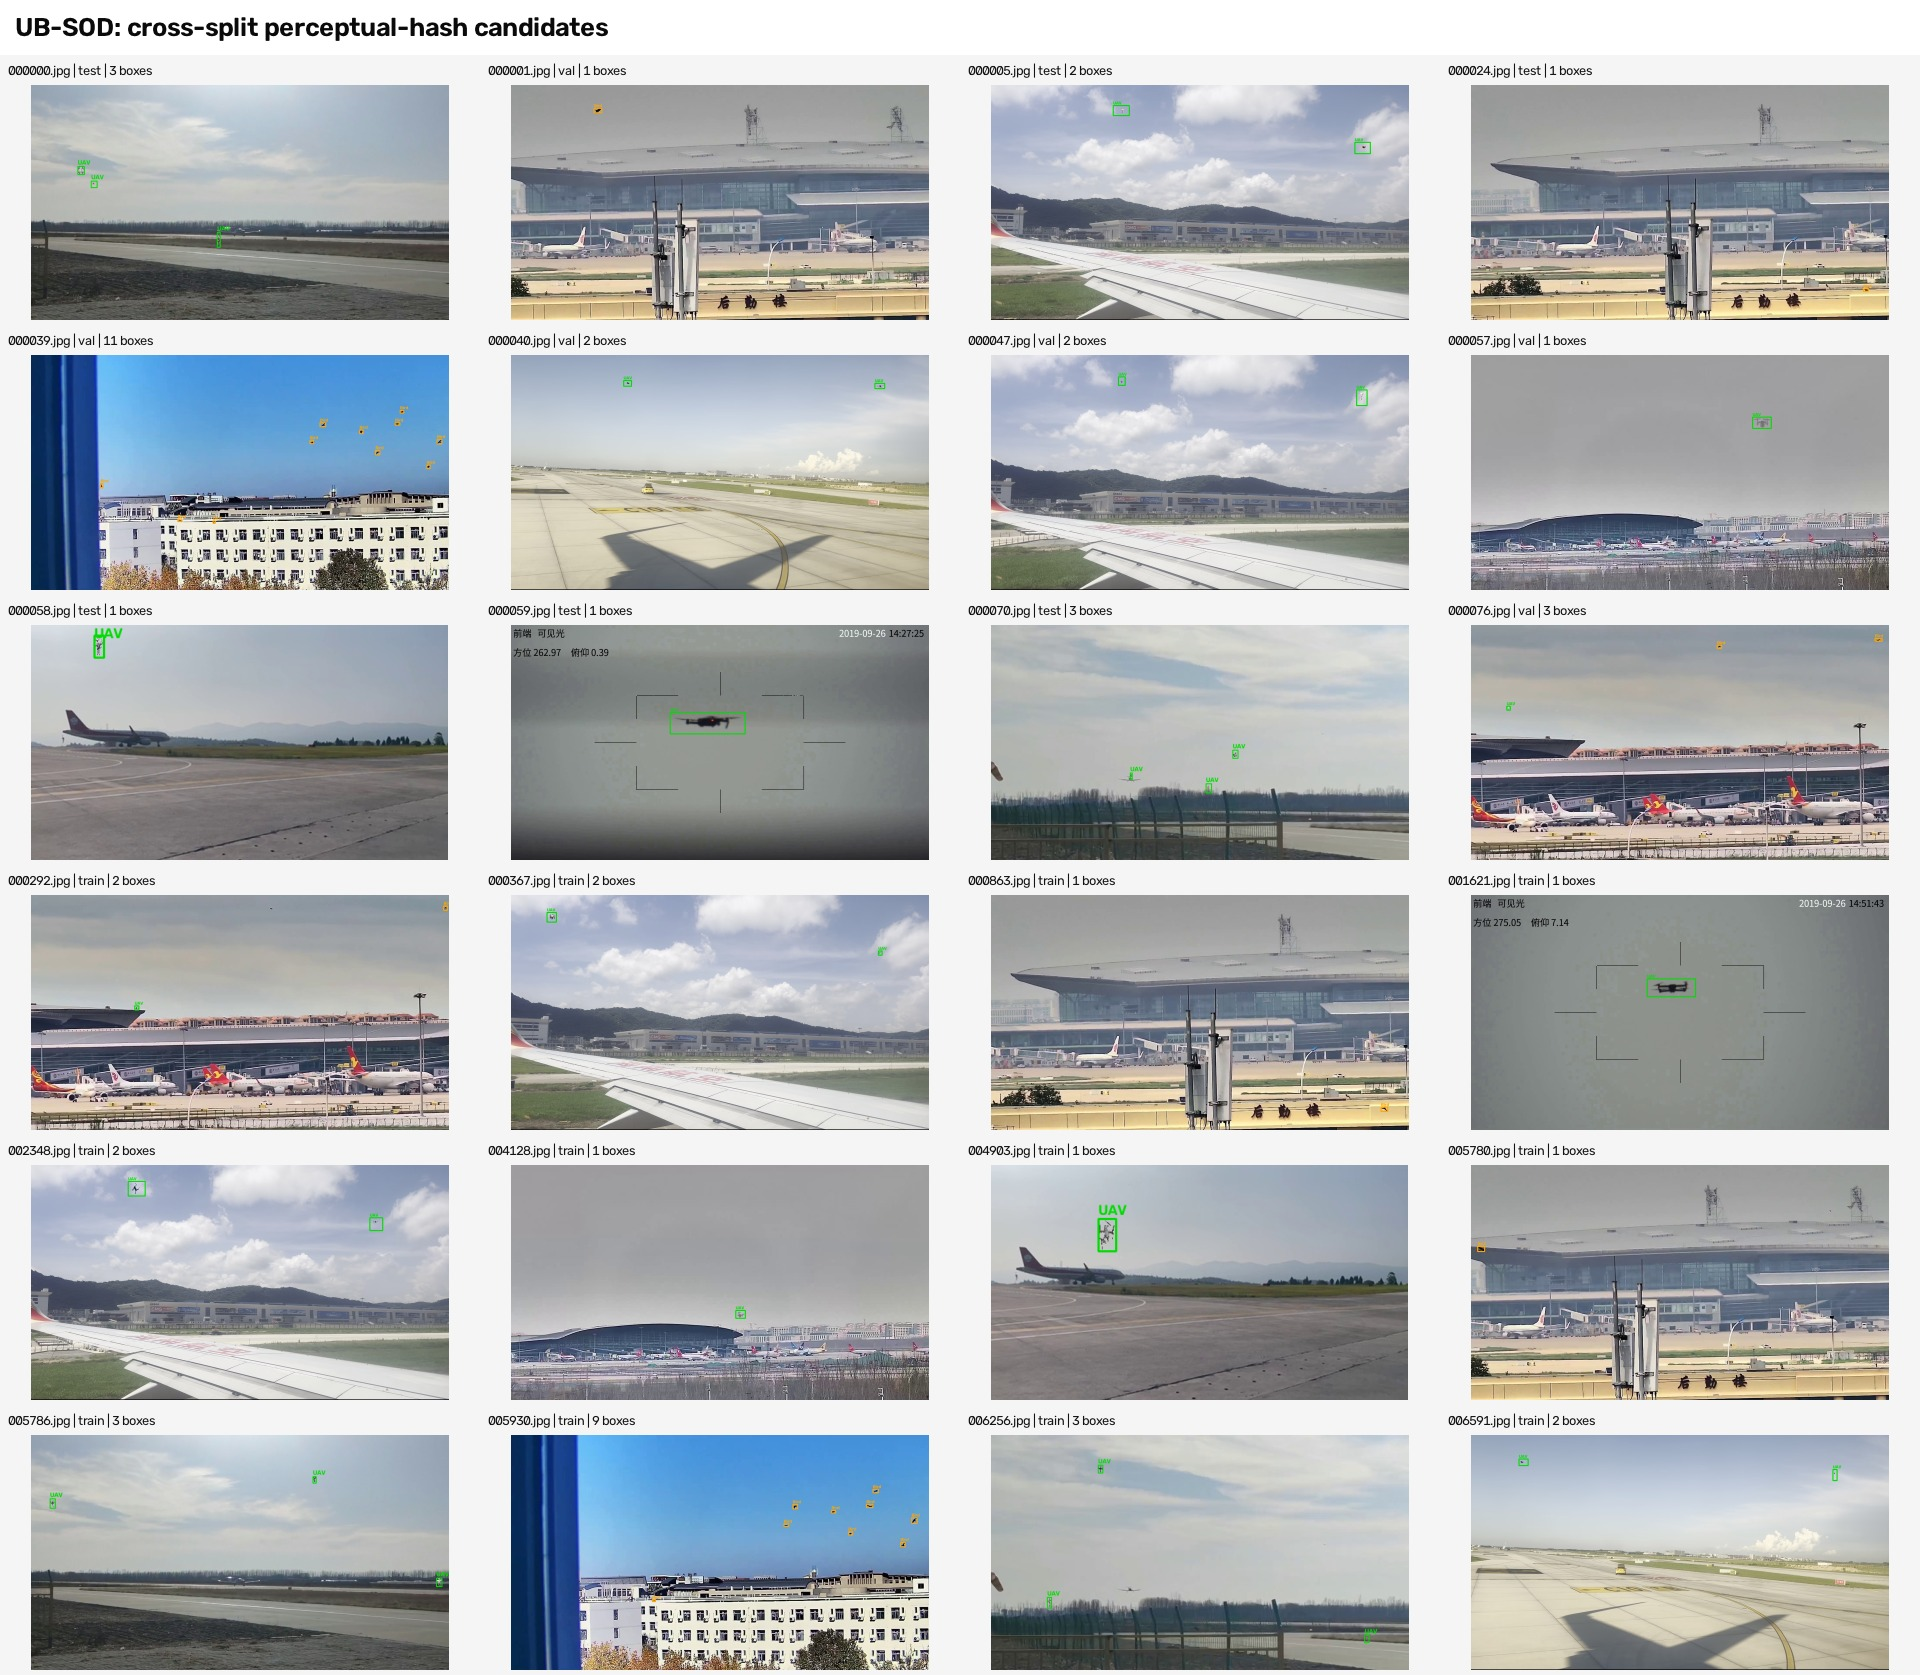

In [5]:
from IPython.display import Image, display
display(Image(filename=str(audit_dir / 'near_duplicate_candidates.jpg')))

### Small-target coverage is useful but demanding

The dataset strongly represents small targets, including 816 boxes with a minimum side below 8 pixels. These cases are useful for training but may be below recoverable detail after resizing to 640 pixels.

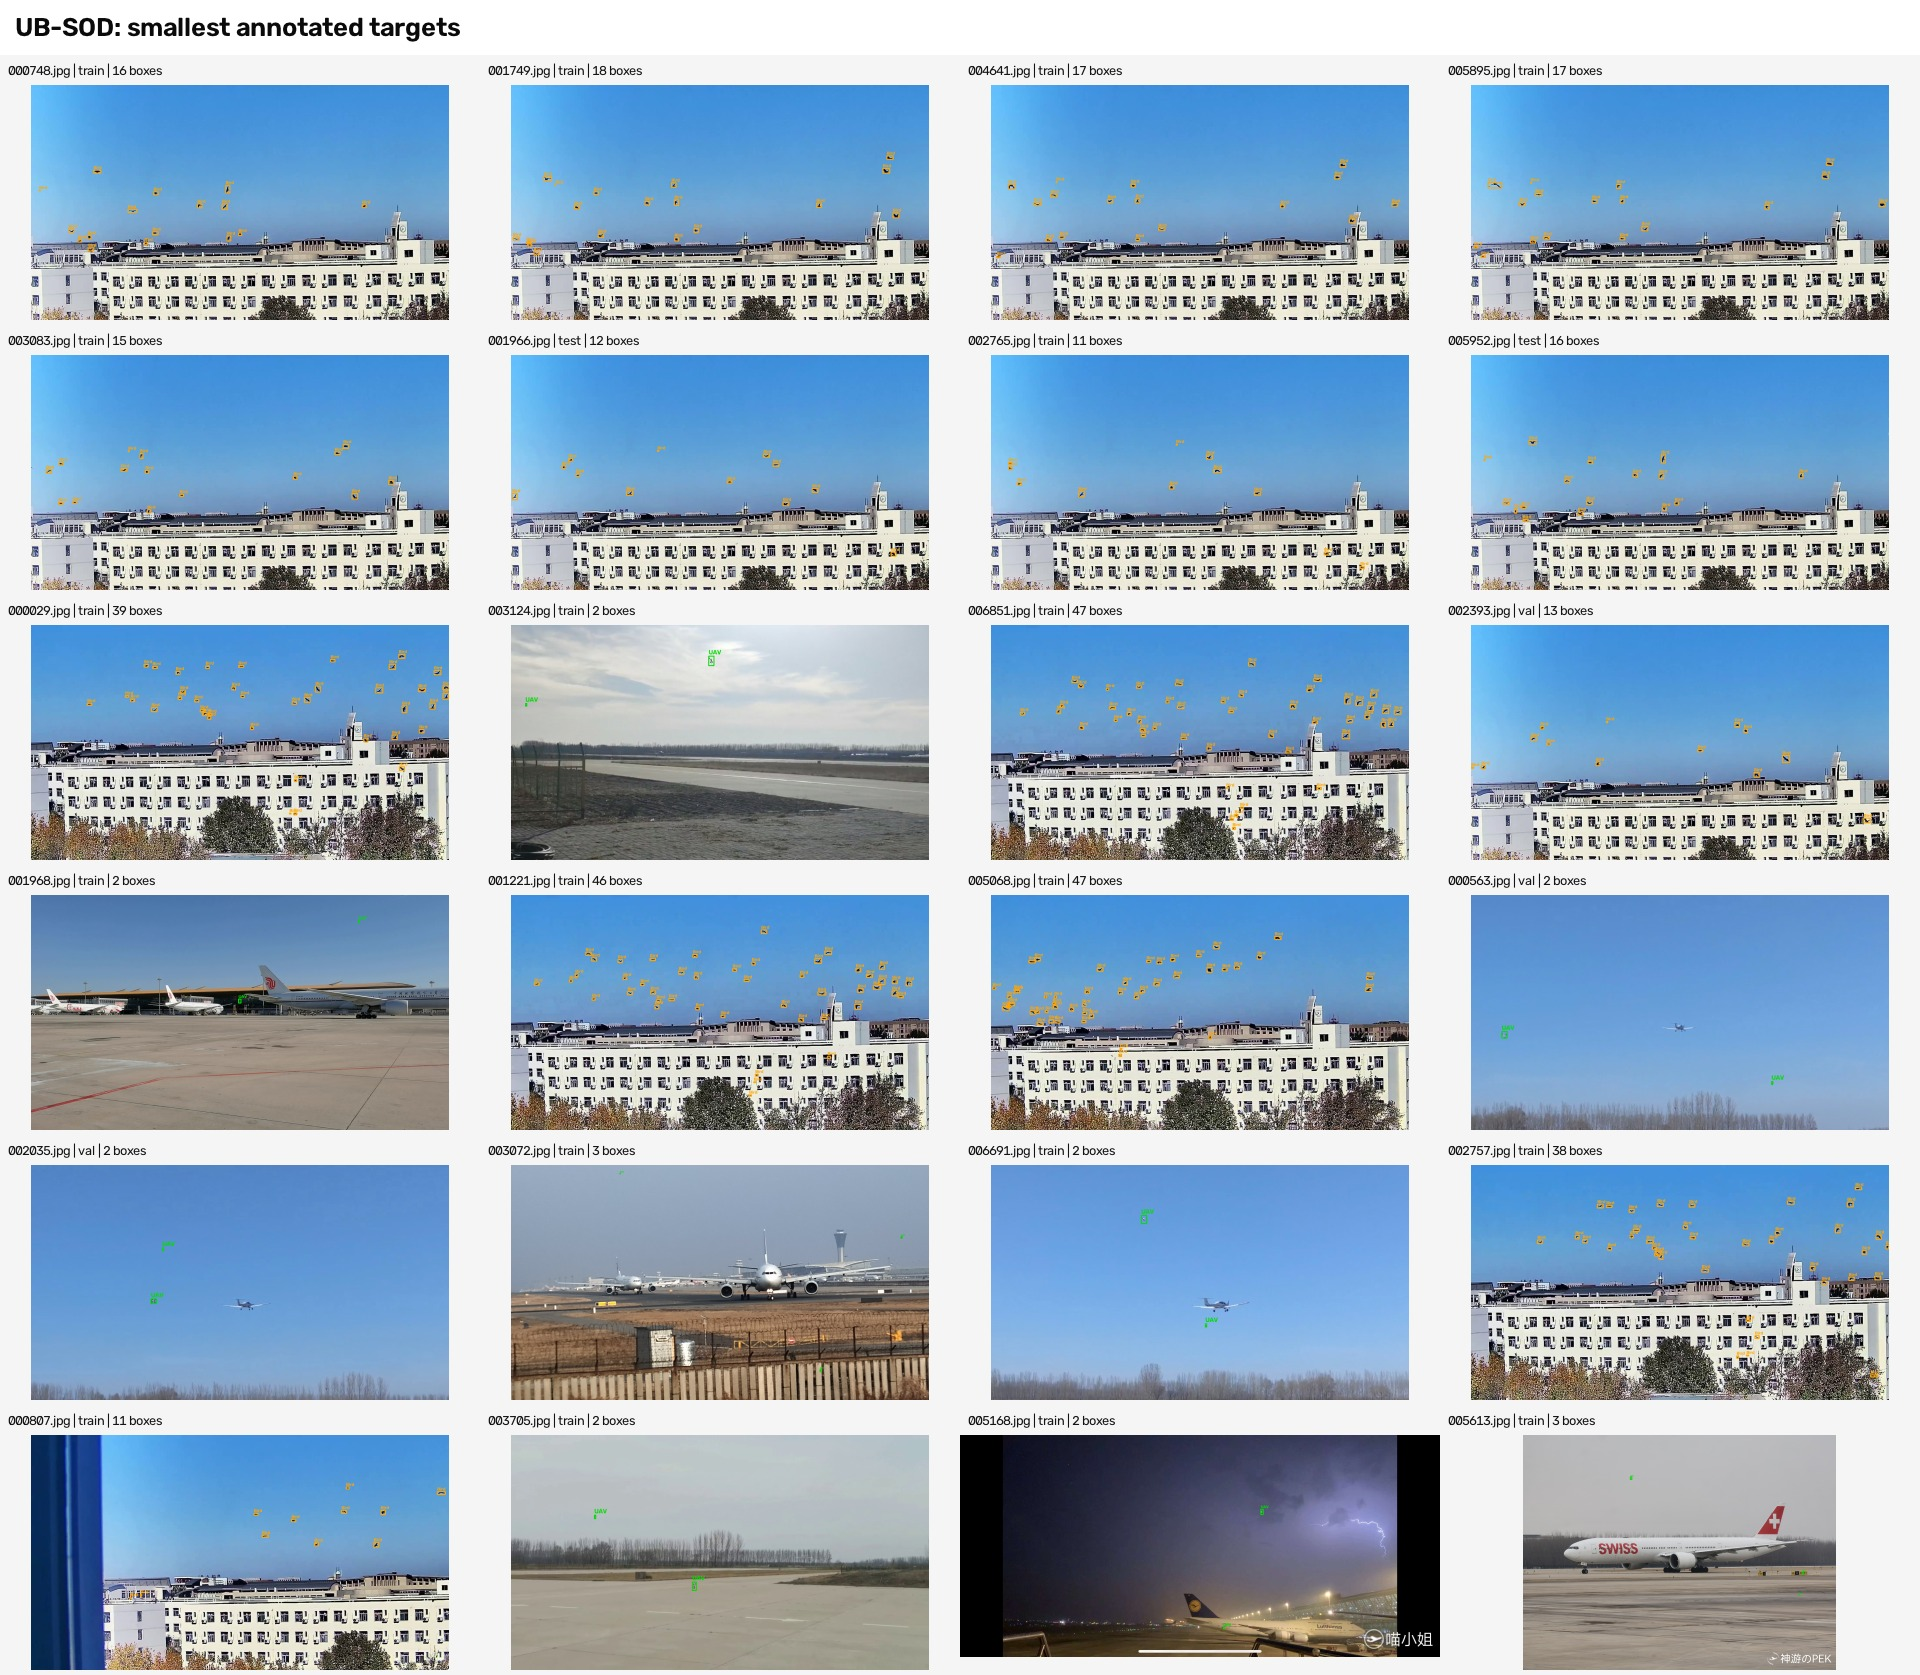

In [6]:
display(Image(filename=str(audit_dir / 'small_targets.jpg')))

## Takeaways

1. **Do not use the supplied validation/test scores as the primary proof of generalization.**
2. **Do not discard the dataset.** Its annotations and small-target coverage are useful for training.
3. Reconstruct splits by recording or visually derived scene group before model selection.
4. Add independent negative videos and an external locked test set. There are no empty-label images in this release.
5. Start YOLO11s only after the split repair; compare YOLO11m with the identical repaired split.